In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('Advertising.csv')

In [4]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
X=df.drop('sales',axis=1)
y=df('sales')

TypeError: 'DataFrame' object is not callable

In [6]:
X=df.drop('sales',axis=1)
y=df['sales']

In [7]:
from sklearn.preprocessing import PolynomialFeatures

In [45]:
poly_convertor= PolynomialFeatures(degree=2, include_bias=False) #bias means the value 1

In [46]:
#poly_convertor.fit(X)

In [47]:
#poly_convertor.transform(X)

In [48]:
poly_convertor.fit_transform(X)

array([[ 230.1 ,   37.8 ,   69.2 , ..., 1428.84, 2615.76, 4788.64],
       [  44.5 ,   39.3 ,   45.1 , ..., 1544.49, 1772.43, 2034.01],
       [  17.2 ,   45.9 ,   69.3 , ..., 2106.81, 3180.87, 4802.49],
       ...,
       [ 177.  ,    9.3 ,    6.4 , ...,   86.49,   59.52,   40.96],
       [ 283.6 ,   42.  ,   66.2 , ..., 1764.  , 2780.4 , 4382.44],
       [ 232.1 ,    8.6 ,    8.7 , ...,   73.96,   74.82,   75.69]])

In [49]:
poly_features= poly_convertor.fit_transform(X)

In [50]:
poly_features.shape

(200, 9)

In [51]:
X.shape

(200, 3)

In [52]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [53]:
poly_features(0)

TypeError: 'numpy.ndarray' object is not callable

In [54]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [55]:
230.1*37.8

8697.779999999999

In [56]:
230.1*69.2

15922.92

In [57]:
37.8*69.2

2615.7599999999998

In [58]:
230.1**2

52946.009999999995

In [59]:
37.8**2

1428.8399999999997

In [60]:
69.2**2

4788.64

In [31]:
#until now we have covered polynomial of degree 2, now lets see what happens if we use polynomial of degree 3

In [40]:
poly_convertor2= PolynomialFeatures(degree=3, include_bias=False) #bias means the value 1

In [41]:
poly_convertor2.fit_transform(X)

array([[2.30100000e+02, 3.78000000e+01, 6.92000000e+01, ...,
        9.88757280e+04, 1.81010592e+05, 3.31373888e+05],
       [4.45000000e+01, 3.93000000e+01, 4.51000000e+01, ...,
        6.96564990e+04, 7.99365930e+04, 9.17338510e+04],
       [1.72000000e+01, 4.59000000e+01, 6.93000000e+01, ...,
        1.46001933e+05, 2.20434291e+05, 3.32812557e+05],
       ...,
       [1.77000000e+02, 9.30000000e+00, 6.40000000e+00, ...,
        5.53536000e+02, 3.80928000e+02, 2.62144000e+02],
       [2.83600000e+02, 4.20000000e+01, 6.62000000e+01, ...,
        1.16776800e+05, 1.84062480e+05, 2.90117528e+05],
       [2.32100000e+02, 8.60000000e+00, 8.70000000e+00, ...,
        6.43452000e+02, 6.50934000e+02, 6.58503000e+02]])

In [42]:
poly_features2= poly_convertor2.fit_transform(X)

In [43]:
poly_features2.shape # seenow there are 19 values bcz now we are getting values of x^3 also

(200, 19)

In [44]:
poly_features2[0]

array([2.30100000e+02, 3.78000000e+01, 6.92000000e+01, 5.29460100e+04,
       8.69778000e+03, 1.59229200e+04, 1.42884000e+03, 2.61576000e+03,
       4.78864000e+03, 1.21828769e+07, 2.00135918e+06, 3.66386389e+06,
       3.28776084e+05, 6.01886376e+05, 1.10186606e+06, 5.40101520e+04,
       9.88757280e+04, 1.81010592e+05, 3.31373888e+05])

### Train | Test Split

In [39]:
from sklearn.model_selection import train_test_split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(poly_features,y, test_size=0.3,random_state=101)

### Model Fitting

In [65]:
from sklearn.linear_model import LinearRegression

In [66]:
poly_model = LinearRegression()

In [67]:
poly_model.fit(X_train,y_train)

LinearRegression()

### Evaluation of model

In [69]:
poly_model.predict(X_test)

array([13.94856153, 19.33480262, 12.31928162, 16.76286337,  7.90210901,
        6.94143792, 20.13372693, 17.50092709, 10.56889   , 20.12551788,
        9.44614537, 14.09935417, 12.05513493, 23.39254049, 19.67508393,
        9.15626258, 12.1163732 ,  9.28149557,  8.44604007, 21.65588129,
        7.05070331, 19.35854208, 27.26716369, 24.58689346,  9.03179421,
       11.81070232, 20.42630125,  9.19390639, 12.74795186,  8.64340674,
        8.66294151, 20.20047377, 10.93673817,  6.84639129, 18.27939359,
        9.47659449, 10.34242145,  9.6657038 ,  7.43347915, 11.03561332,
       12.65731013, 10.65459946, 11.20971496,  7.46199023, 11.38224982,
       10.27331262,  6.15573251, 15.50893362, 13.36092889, 22.71839277,
       10.40389682, 13.21622701, 14.23622207, 11.8723677 , 11.68463616,
        5.62217738, 25.03778913,  9.53507734, 17.37926571, 15.7534364 ])

In [70]:
test_pred= poly_model.predict(X_test)

In [71]:
X_test

array([[7.470000e+01, 4.940000e+01, 4.570000e+01, 5.580090e+03,
        3.690180e+03, 3.413790e+03, 2.440360e+03, 2.257580e+03,
        2.088490e+03],
       [2.554000e+02, 2.690000e+01, 5.500000e+00, 6.522916e+04,
        6.870260e+03, 1.404700e+03, 7.236100e+02, 1.479500e+02,
        3.025000e+01],
       [1.129000e+02, 1.740000e+01, 3.860000e+01, 1.274641e+04,
        1.964460e+03, 4.357940e+03, 3.027600e+02, 6.716400e+02,
        1.489960e+03],
       [1.098000e+02, 4.780000e+01, 5.140000e+01, 1.205604e+04,
        5.248440e+03, 5.643720e+03, 2.284840e+03, 2.456920e+03,
        2.641960e+03],
       [3.150000e+01, 2.460000e+01, 2.200000e+00, 9.922500e+02,
        7.749000e+02, 6.930000e+01, 6.051600e+02, 5.412000e+01,
        4.840000e+00],
       [1.940000e+01, 1.600000e+01, 2.230000e+01, 3.763600e+02,
        3.104000e+02, 4.326200e+02, 2.560000e+02, 3.568000e+02,
        4.972900e+02],
       [2.627000e+02, 2.880000e+01, 1.590000e+01, 6.901129e+04,
        7.565760e+03, 4.176930

In [72]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [73]:
MAE= mean_absolute_error(y_test,test_pred)

In [74]:
MAE

0.48967980448037096

In [75]:
MSE= mean_squared_error(y_test,test_pred)
MSE

0.44175055104035904

In [76]:
RMSE= np.sqrt(MSE)
RMSE

np.float64(0.6646431757269152)

In [79]:
# note that in case of linear regresion we got rmse as 1.5 something, but with polynomial regression we got rmse as 0.66, which is a very good thing

### Choosing a Model
#### Adjusting parameters

In [91]:
# Traning error per degree
train_rmse_errors= []

# Test error per degree
test_rmse_errors= []

for d in range(1,10):
    # create a polynomial dataset for degree d
    polynomial_convertor= PolynomialFeatures(degree=d, include_bias=False)
    polynomial_features= polynomial_convertor.fit_transform(X)

    # train test split
    X_train, X_test, y_train, y_test= train_test_split(polynomial_features,y, test_size=0.3, random_state=80)

    #train on this poly set
    model= LinearRegression()
    model.fit(X_train,y_train)

    # predict on both train and test data
    train_pred= model.predict(X_train)
    test_pred= model.predict(X_test)

    # cacutate errors
    train_RMSE= np.sqrt(mean_squared_error(y_train,train_pred))
    test_RMSE= np.sqrt(mean_squared_error(y_test,test_pred))

    # append errors
    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)

In [92]:
train_rmse_errors

[np.float64(1.5411268713201836),
 np.float64(0.5058118690673488),
 np.float64(0.3647231674288148),
 np.float64(0.2878181927346845),
 np.float64(0.24269065146000557),
 np.float64(0.2682847705907577),
 np.float64(0.3242812149049977),
 np.float64(0.3903552596923894),
 np.float64(0.569493324947775)]

In [93]:
test_rmse_errors

[np.float64(1.9703221949203542),
 np.float64(0.8142078249893573),
 np.float64(0.7232615053544192),
 np.float64(0.8698622958190846),
 np.float64(3.2317412100783756),
 np.float64(6.7516247526739726),
 np.float64(38.0485311034441),
 np.float64(1404.5170260178493),
 np.float64(9744.587389717512)]

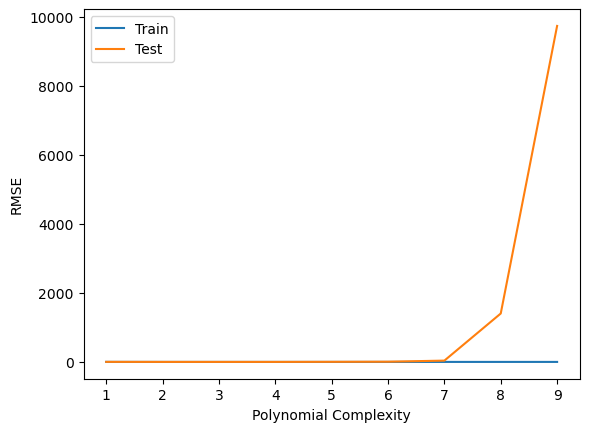

In [94]:
plt.plot(range(1,10),train_rmse_errors,label='Train')
plt.plot(range(1,10),test_rmse_errors,label='Test')
plt.xlabel('Polynomial Complexity')
plt.ylabel('RMSE')
plt.legend()

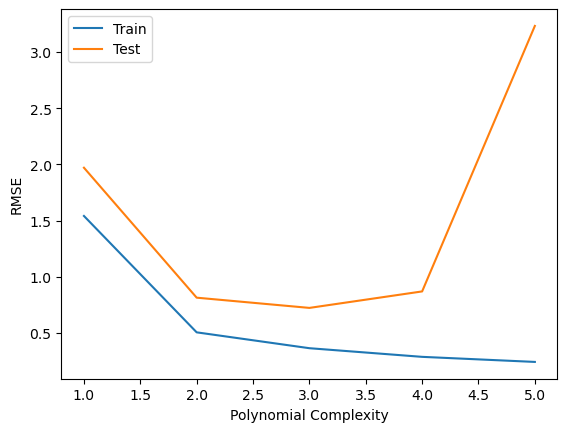

In [95]:
plt.plot(range(1,6),train_rmse_errors[0:5],label='Train')
plt.plot(range(1,6),test_rmse_errors[0:5],label='Test')
plt.xlabel('Polynomial Complexity')
plt.ylabel('RMSE')
plt.legend()

### Finalyze model

In [96]:
final_poly_conv= PolynomialFeatures(degree=3, include_bias=False)#final_poly_convertor

In [97]:
final_model= LinearRegression()

In [101]:
final_poly_conv.fit_transform(X) # will give array of degree 3

array([[2.30100000e+02, 3.78000000e+01, 6.92000000e+01, ...,
        9.88757280e+04, 1.81010592e+05, 3.31373888e+05],
       [4.45000000e+01, 3.93000000e+01, 4.51000000e+01, ...,
        6.96564990e+04, 7.99365930e+04, 9.17338510e+04],
       [1.72000000e+01, 4.59000000e+01, 6.93000000e+01, ...,
        1.46001933e+05, 2.20434291e+05, 3.32812557e+05],
       ...,
       [1.77000000e+02, 9.30000000e+00, 6.40000000e+00, ...,
        5.53536000e+02, 3.80928000e+02, 2.62144000e+02],
       [2.83600000e+02, 4.20000000e+01, 6.62000000e+01, ...,
        1.16776800e+05, 1.84062480e+05, 2.90117528e+05],
       [2.32100000e+02, 8.60000000e+00, 8.70000000e+00, ...,
        6.43452000e+02, 6.50934000e+02, 6.58503000e+02]])

In [102]:
final_model.fit(final_poly_conv.fit_transform(X),y)

LinearRegression()

### Saving model and convertor

In [103]:
from joblib import dump,load

In [104]:
dump(final_model,'sales_polynomial_model.joblib')

['sales_polynomial_model.joblib']

In [105]:
dump(final_poly_conv,'poly_convertor.joblib')

['poly_convertor.joblib']

### Loading model and predicting new data

In [106]:
loaded_poly= load('poly_convertor.joblib')

In [107]:
loaded_model= load('sales_polynomial_model.joblib')

In [108]:
ad_camp=[[101,78,90],[112,98,34],[121,54,345],[345,436,78]]

In [111]:
poly_camp_ad= loaded_poly.transform(ad_camp) # bcz new data has to be transformed before we go for the prediction

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [112]:
final_model.predict(poly_camp_ad)

array([ 22.47033937,  26.91966015, -37.40132564, 513.05472342])